In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

# Q5:

## load the data from the csv files

In [2]:
text_examples_df = df = pd.read_csv('TextExamples.csv')
text_pretrained_df = pd.read_csv('TextPretrainedEmbeddings.csv')

In [3]:
y_map = {"negative": 0, "positive": 1}
Y = text_examples_df['sentiment'].map(y_map).to_numpy()
X = text_pretrained_df.to_numpy()

## Test the classifiers and determine which is the best one for our use case

### KNN

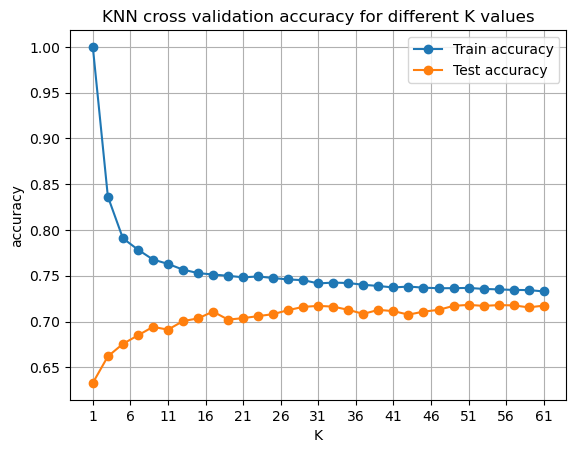

In [4]:
KNN_train_accuracy = []
KNN_test_accuracy = []
K = range(1, 62, 2)
for k in K:
    KNN = KNeighborsClassifier(n_neighbors=k)
    cv_results = cross_validate(KNN, X, Y, cv=5, return_train_score=True)
    KNN_train_accuracy.append(np.mean(cv_results['train_score']))
    KNN_test_accuracy.append(np.mean(cv_results['test_score']))
plt.figure()
plt.plot(K, KNN_train_accuracy, '-o', label="Train accuracy")
plt.plot(K, KNN_test_accuracy, '-o', label="Test accuracy")
plt.title("KNN cross validation accuracy for different K values")
plt.legend()
plt.xlabel("K")
plt.ylabel("accuracy")
plt.xticks(range(1, 62, 5))
plt.grid()
plt.show()

### LDA

In [5]:
LDA = LinearDiscriminantAnalysis()
cv_results = cross_validate(LDA, X, Y, cv=5, return_train_score=True)
LDA_train_accuracy = np.mean(cv_results['train_score'])
LDA_test_accuracy = np.mean(cv_results['test_score'])
print(f"Cross validation train accuracy for LDA is: {LDA_train_accuracy}")
print(f"Cross validation test accuracy for LDA is: {LDA_test_accuracy}")

Cross validation train accuracy for LDA is: 0.7937275152574206
Cross validation test accuracy for LDA is: 0.7802632070746713


### QDA

In [6]:
QDA = QuadraticDiscriminantAnalysis()
cv_results = cross_validate(QDA, X, Y, cv=5, return_train_score=True)
QDA_train_accuracy = np.mean(cv_results['train_score'])
QDA_test_accuracy = np.mean(cv_results['test_score'])
print(f"Cross validation train accuracy for QDA is: {QDA_train_accuracy}")
print(f"Cross validation test accuracy for QDA is: {QDA_test_accuracy}")

Cross validation train accuracy for QDA is: 0.8475678672842445
Cross validation test accuracy for QDA is: 0.7269725579900278


### GNB

In [7]:
GNB = GaussianNB()
cv_results = cross_validate(GNB, X, Y, cv=5, return_train_score=True)
GNB_train_accuracy = np.mean(cv_results['train_score'])
GNB_test_accuracy = np.mean(cv_results['test_score'])
print(f"Cross validation train accuracy for GNB is: {GNB_train_accuracy}")
print(f"Cross validation test accuracy for GNB is: {GNB_test_accuracy}")

Cross validation train accuracy for GNB is: 0.6952714598023676
Cross validation test accuracy for GNB is: 0.6881635307573278


### Decision Tree: min_samples_leaf

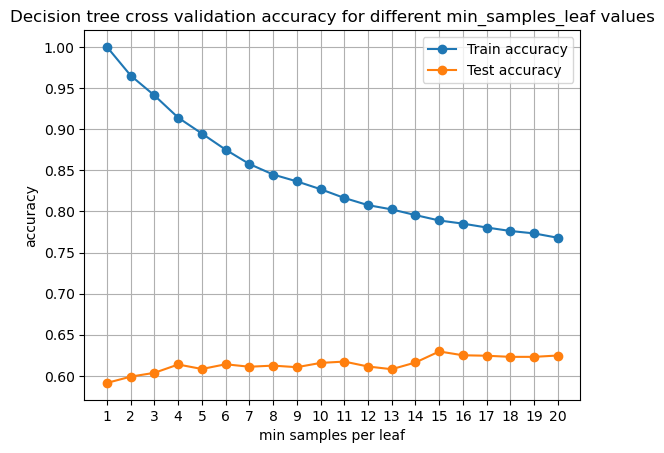

In [8]:
tree_train_accuracy = []
tree_test_accuracy = []
leafs = range(1, 21)
for n in leafs:
    decision_tree = tree.DecisionTreeClassifier(min_samples_leaf=n)
    cv_results = cross_validate(decision_tree, X, Y, cv=5, return_train_score=True)
    tree_train_accuracy.append(np.mean(cv_results['train_score']))
    tree_test_accuracy.append(np.mean(cv_results['test_score']))
plt.figure()
plt.plot(leafs, tree_train_accuracy, '-o', label="Train accuracy")
plt.plot(leafs, tree_test_accuracy, '-o', label="Test accuracy")
plt.title("Decision tree cross validation accuracy for different min_samples_leaf values")
plt.legend()
plt.xlabel("min samples per leaf")
plt.ylabel("accuracy")
plt.xticks(leafs)
plt.grid()
plt.show()

### Decision Tree: max_depth

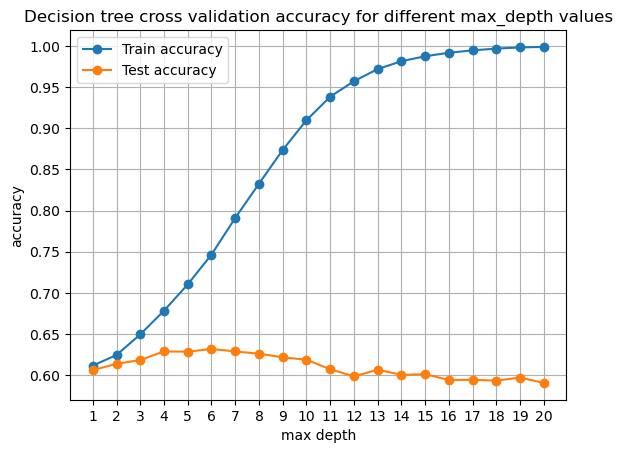

In [9]:
tree_train_accuracy = []
tree_test_accuracy = []
depth = range(1, 21)
for n in leafs:
    decision_tree = tree.DecisionTreeClassifier(max_depth=n)
    cv_results = cross_validate(decision_tree, X, Y, cv=5, return_train_score=True)
    tree_train_accuracy.append(np.mean(cv_results['train_score']))
    tree_test_accuracy.append(np.mean(cv_results['test_score']))
plt.figure()
plt.plot(depth, tree_train_accuracy, '-o', label="Train accuracy")
plt.plot(depth, tree_test_accuracy, '-o', label="Test accuracy")
plt.title("Decision tree cross validation accuracy for different max_depth values")
plt.legend()
plt.xlabel("max depth")
plt.ylabel("accuracy")
plt.xticks(depth)
plt.grid()
plt.show()

### Random Forest

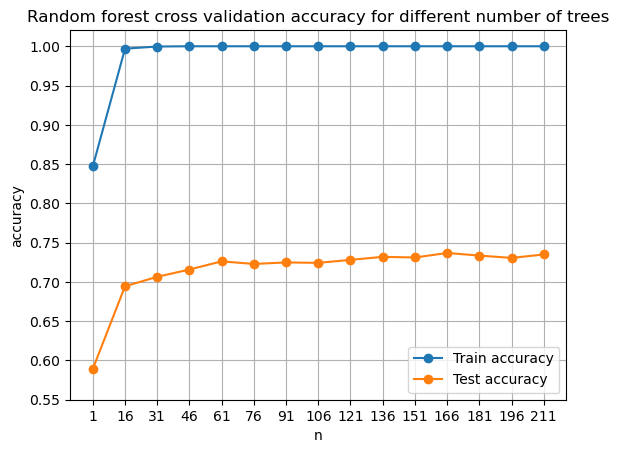

In [10]:
forest_train_accuracy = []
forest_test_accuracy = []
N = range(1, 212, 15)
for n in N:
    random_forest = RandomForestClassifier(n_estimators=n)
    cv_results = cross_validate(random_forest, X, Y, cv=5, return_train_score=True)
    forest_train_accuracy.append(np.mean(cv_results['train_score']))
    forest_test_accuracy.append(np.mean(cv_results['test_score']))
plt.figure()
plt.plot(N, forest_train_accuracy, '-o', label="Train accuracy")
plt.plot(N, forest_test_accuracy, '-o', label="Test accuracy")
plt.title("Random forest cross validation accuracy for different number of trees")
plt.legend()
plt.xlabel("n")
plt.ylabel("accuracy")
plt.xticks(N)
plt.yticks([x / 100.0 for x in range(55, 105, 5)])
plt.grid()
plt.show()

# Q6: repeat Q5 for finetuned embeddings

## load the data from the csv files

In [11]:
text_finetuned_df = pd.read_csv('TextFinetunedEmbeddings.csv')
X = text_finetuned_df.to_numpy()

## Test the classifiers and determine which is the best one for our use case

### KNN

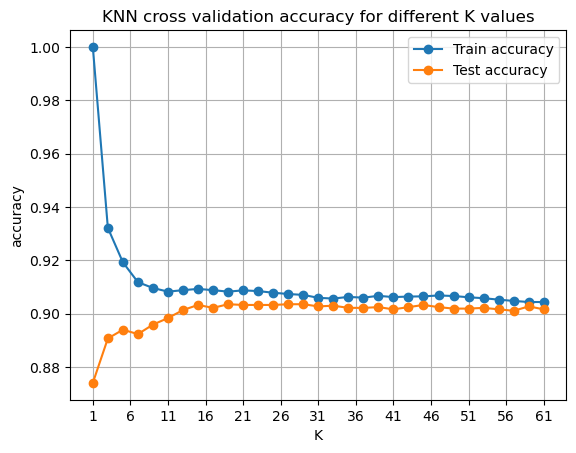

In [12]:
KNN_train_accuracy = []
KNN_test_accuracy = []
K = range(1, 62, 2)
for k in K:
    KNN = KNeighborsClassifier(n_neighbors=k)
    cv_results = cross_validate(KNN, X, Y, cv=5, return_train_score=True)
    KNN_train_accuracy.append(np.mean(cv_results['train_score']))
    KNN_test_accuracy.append(np.mean(cv_results['test_score']))
plt.figure()
plt.plot(K, KNN_train_accuracy, '-o', label="Train accuracy")
plt.plot(K, KNN_test_accuracy, '-o', label="Test accuracy")
plt.title("KNN cross validation accuracy for different K values")
plt.legend()
plt.xlabel("K")
plt.ylabel("accuracy")
plt.xticks(range(1, 62, 5))
plt.grid()
plt.show()

### LDA

In [13]:
LDA = LinearDiscriminantAnalysis()
cv_results = cross_validate(LDA, X, Y, cv=5, return_train_score=True)
LDA_train_accuracy = np.mean(cv_results['train_score'])
LDA_test_accuracy = np.mean(cv_results['test_score'])
print(f"Cross validation train accuracy for LDA is: {LDA_train_accuracy}")
print(f"Cross validation test accuracy for LDA is: {LDA_test_accuracy}")

Cross validation train accuracy for LDA is: 0.9061214740843215
Cross validation test accuracy for LDA is: 0.9010588833322121


### QDA

In [14]:
QDA = QuadraticDiscriminantAnalysis()
cv_results = cross_validate(QDA, X, Y, cv=5, return_train_score=True)
QDA_train_accuracy = np.mean(cv_results['train_score'])
QDA_test_accuracy = np.mean(cv_results['test_score'])
print(f"Cross validation train accuracy for QDA is: {QDA_train_accuracy}")
print(f"Cross validation test accuracy for QDA is: {QDA_test_accuracy}")

Cross validation train accuracy for QDA is: 0.922382808634888
Cross validation test accuracy for QDA is: 0.9032454232169421


### GNB

In [15]:
GNB = GaussianNB()
cv_results = cross_validate(GNB, X, Y, cv=5, return_train_score=True)
GNB_train_accuracy = np.mean(cv_results['train_score'])
GNB_test_accuracy = np.mean(cv_results['test_score'])
print(f"Cross validation train accuracy for GNB is: {GNB_train_accuracy}")
print(f"Cross validation test accuracy for GNB is: {GNB_test_accuracy}")

Cross validation train accuracy for GNB is: 0.8976492650861305
Cross validation test accuracy for GNB is: 0.8966865510977552


### Decision Tree: min_samples_leaf

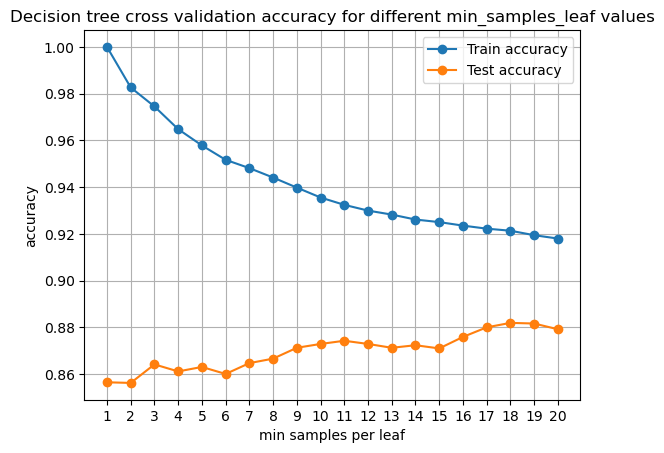

In [16]:
tree_train_accuracy = []
tree_test_accuracy = []
leafs = range(1, 21)
for n in leafs:
    decision_tree = tree.DecisionTreeClassifier(min_samples_leaf=n)
    cv_results = cross_validate(decision_tree, X, Y, cv=5, return_train_score=True)
    tree_train_accuracy.append(np.mean(cv_results['train_score']))
    tree_test_accuracy.append(np.mean(cv_results['test_score']))
plt.figure()
plt.plot(leafs, tree_train_accuracy, '-o', label="Train accuracy")
plt.plot(leafs, tree_test_accuracy, '-o', label="Test accuracy")
plt.title("Decision tree cross validation accuracy for different min_samples_leaf values")
plt.legend()
plt.xlabel("min samples per leaf")
plt.ylabel("accuracy")
plt.xticks(leafs)
plt.grid()
plt.show()

### Decision Tree: max_depth

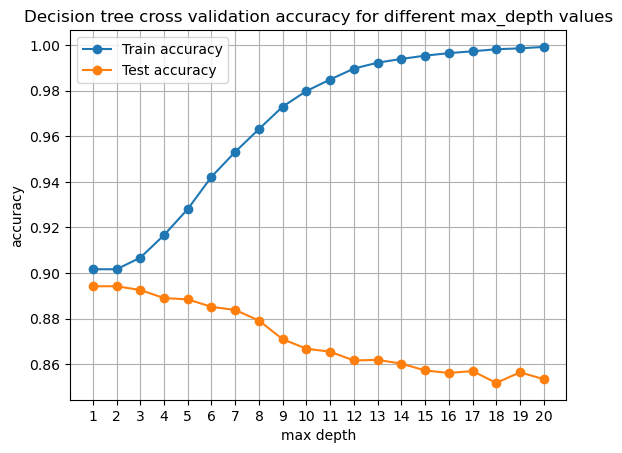

In [17]:
tree_train_accuracy = []
tree_test_accuracy = []
depth = range(1, 21)
for n in leafs:
    decision_tree = tree.DecisionTreeClassifier(max_depth=n)
    cv_results = cross_validate(decision_tree, X, Y, cv=5, return_train_score=True)
    tree_train_accuracy.append(np.mean(cv_results['train_score']))
    tree_test_accuracy.append(np.mean(cv_results['test_score']))
plt.figure()
plt.plot(depth, tree_train_accuracy, '-o', label="Train accuracy")
plt.plot(depth, tree_test_accuracy, '-o', label="Test accuracy")
plt.title("Decision tree cross validation accuracy for different max_depth values")
plt.legend()
plt.xlabel("max depth")
plt.ylabel("accuracy")
plt.xticks(depth)
plt.grid()
plt.show()

### Random Forest

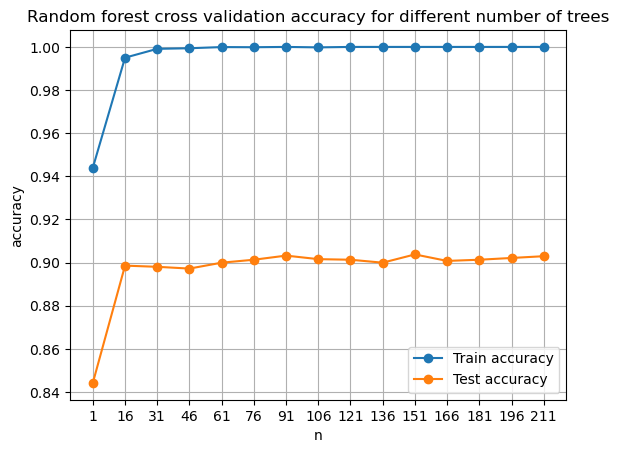

In [19]:
forest_train_accuracy = []
forest_test_accuracy = []
N = range(1, 212, 15)
for n in N:
    random_forest = RandomForestClassifier(n_estimators=n)
    cv_results = cross_validate(random_forest, X, Y, cv=5, return_train_score=True)
    forest_train_accuracy.append(np.mean(cv_results['train_score']))
    forest_test_accuracy.append(np.mean(cv_results['test_score']))
plt.figure()
plt.plot(N, forest_train_accuracy, '-o', label="Train accuracy")
plt.plot(N, forest_test_accuracy, '-o', label="Test accuracy")
plt.title("Random forest cross validation accuracy for different number of trees")
plt.legend()
plt.xlabel("n")
plt.ylabel("accuracy")
plt.xticks(N)
plt.grid()
plt.show()